Лабораторна робота 2. Сєров Єгор ФІТ 3-10

---



# Завдання 1

**Був присутній на парі** +

Обробка та нааліз даних про ВВП країн. Датасет було отримано з Вікіпедії з використанням бібілотеки Pandas.

1. Вивести перші 5 рядків датасета

In [4]:
import io
import requests
import pandas as pd

# Завантажуємо сторінку з Вікіпедії з передачею User-Agent
url = "https://en.wikipedia.org/wiki/List_of_countries_by_GDP_(nominal)"
headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}
response = requests.get(url, headers=headers)

# Зчитуємо таблиці через pandas
tables = pd.read_html(io.StringIO(response.text))

# Знаходимо таблицю з даними про країни та ВВП
df = None
for t in tables:
    if any("Country" in str(col) for col in t.columns):
        df = t
        break

# Спрощуємо назви стовпців, якщо вони дворівневі (MultiIndex)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = [
        " ".join([str(c) for c in col if "Unnamed" not in str(c)]).strip()
        for col in df.columns
    ]

# 1. Виведення перших 5 рядків
print("Перші 5 рядків датасету:")
print(df.head(5))

Перші 5 рядків датасету:
  Country/Territory IMF (2026)[1] World Bank (2025)[6]  \
0             World     126295331            118350166   
1     United States      32383920             30769700   
2        China[n 1]      20851593             19498039   
3           Germany       5452858              5050923   
4             Japan       4379253              4435163   

  United Nations (2024)[7]  
0                111565144  
1                 29298000  
2                 18743802  
3                  4659929  
4                  4026211  


2.	Визначити розмір датасета.

In [5]:
import io
import requests
import pandas as pd

# Завантаження та парсинг таблиці
url = "https://en.wikipedia.org/wiki/List_of_countries_by_GDP_(nominal)"
headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}
response = requests.get(url, headers=headers)

tables = pd.read_html(io.StringIO(response.text))

df = None
for t in tables:
    if any("Country" in str(col) for col in t.columns):
        df = t
        break

# 2. Визначення розмірності датасету
rows, cols = df.shape

print(f"Повний розмір датасету (shape): {df.shape}")
print(f"Кількість записів (рядків): {rows}")
print(f"Кількість ознак (стовпців): {cols}")

Повний розмір датасету (shape): (222, 4)
Кількість записів (рядків): 222
Кількість ознак (стовпців): 4


 3.	Визначити оптимальну кількість стовпців (видалити зайві, на власний розсуд).

In [22]:
import io
import requests
import pandas as pd

# Завантажуємо сторінку Вікіпедії
url = "https://en.wikipedia.org/wiki/List_of_countries_by_GDP_(nominal)"
headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}
response = requests.get(url, headers=headers)
tables = pd.read_html(io.StringIO(response.text))

# Знаходимо таблицю, де є дані про країни та організації (IMF, World Bank)
df = None
for t in tables:
    cols_str = " ".join([str(c) for c in t.columns])
    if "Country" in cols_str and "IMF" in cols_str:
        df = t
        break

# Якщо назви колонок дворівневі (MultiIndex) — зводимо до одного рядка
if isinstance(df.columns, pd.MultiIndex):
    df.columns = [
        " ".join([str(c) for c in col if "Unnamed" not in str(c)]).strip()
        for col in df.columns
    ]

# 3. Вибираємо оптимальні 4 стовпці: Назва країни + оцінки IMF, World Bank, United Nations
clean_df = df.iloc[:, [0, 1, 2, 3]].copy()
clean_df.columns = ["Country", "GDP_IMF", "GDP_WB", "GDP_UN"]

# Прибираємо рядок 'World' або підсумкові агреговані записи, якщо вони є на початку
clean_df = clean_df[~clean_df["Country"].str.contains("World", case=False, na=False)].reset_index(drop=True)

print(f"Розмір після відбору стовпців: {clean_df.shape}")
print(clean_df.head(5))

Розмір після відбору стовпців: (221, 4)
          Country   GDP_IMF    GDP_WB    GDP_UN
0   United States  32383920  30769700  29298000
1      China[n 1]  20851593  19498039  18743802
2         Germany   5452858   5050923   4659929
3           Japan   4379253   4435163   4026211
4  United Kingdom   4264794   4002588   3685881


4.	Замініть у таблиці значення "—" на значення NaN. Перевірити наявність пропущених значень. При наявності, замінити пропущені значення на середнє значення.

In [13]:
import numpy as np

# 1. Заміна тире ("—", "-", "–") та подібних символів на np.nan
clean_df = clean_df.replace(["—", "–", "-", "— "], np.nan)

# 2. Очищення числових стовпців від ком/пробілів та приведення до числового типу (float)
for col in clean_df.columns:
    if col != "Country":
        # Прибираємо коми та нерозривні пробіли, якщо вони є у числових рядках
        clean_df[col] = clean_df[col].astype(str).str.replace(",", "").str.strip()
        clean_df[col] = pd.to_numeric(clean_df[col], errors="coerce")

# 3. Перевірка наявності пропущених значень
print("Кількість пропущених значень по кожному стовпцю:")
print(clean_df.isna().sum())

# 4. Заміна пропущених значень на середнє значення стовпця (для числових даних)
for col in clean_df.select_dtypes(include=[np.number]).columns:
    if clean_df[col].isna().sum() > 0:
        mean_val = clean_df[col].mean()
        clean_df[col] = clean_df[col].fillna(mean_val)

print("\nПеревірка пропусків після заміни на середнє:")
print(clean_df.isna().sum())

print("\nПерші 5 рядків після обробки:")
print(clean_df.head(5))

Кількість пропущених значень по кожному стовпцю:
Country             0
GDP_IMF_Mln_USD    31
dtype: int64

Перевірка пропусків після заміни на середнє:
Country            0
GDP_IMF_Mln_USD    0
dtype: int64

Перші 5 рядків після обробки:
         Country  GDP_IMF_Mln_USD
0          World      126295331.0
1  United States       32383920.0
2     China[n 1]       20851593.0
3        Germany        5452858.0
4          Japan        4379253.0


5. Ще раз вивести датасет

In [14]:
#  Виведення датасету (перші та останні рядки або повний вигляд)
print("Вигляд датасету після попередньої обробки:")
print(clean_df.head(10))

# Для швидкого огляду типів даних та кількості заповнених рядків:
print("\nЗагальна інформація про датасет:")
clean_df.info()

Вигляд датасету після попередньої обробки:
          Country  GDP_IMF_Mln_USD
0           World      126295331.0
1   United States       32383920.0
2      China[n 1]       20851593.0
3         Germany        5452858.0
4           Japan        4379253.0
5  United Kingdom        4264794.0
6           India        4153191.0
7          France        3596094.0
8           Italy        2738164.0
9          Russia        2656452.0

Загальна інформація про датасет:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 222 entries, 0 to 221
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Country          222 non-null    object 
 1   GDP_IMF_Mln_USD  222 non-null    float64
dtypes: float64(1), object(1)
memory usage: 3.6+ KB


6.	Перевірити наявність дублікатів. При наявності видалити дублікати.

In [16]:
#  Перевірка наявності дублікатів
duplicates_count = clean_df.duplicated().sum()
print(f"Кількість повних рядків-дублікатів: {duplicates_count}")

# Перевірка дублікатів конкретно за назвою країни (якщо є)
country_duplicates = clean_df.duplicated(subset=["Country"]).sum()
print(f"Кількість дублювань за назвою країни: {country_duplicates}")

# Якщо дублікати знайдено — видаляємо їх
if duplicates_count > 0 or country_duplicates > 0:
    # Видаляємо дублікати, залишаючи перший знайдений запис
    clean_df = clean_df.drop_duplicates(subset=["Country"], keep="first").reset_index(drop=True)
    print("\nДублікати успішно видалено.")
else:
    print("\nДублікатів у датасеті не виявлено.")

# Підсумкова розмірність після очищення від дублікатів
print(f"Поточний розмір датасету: {clean_df.shape}")

Кількість повних рядків-дублікатів: 0
Кількість дублювань за назвою країни: 0

Дублікатів у датасеті не виявлено.
Поточний розмір датасету: (222, 2)


7.	Вивести описову статистику датасету describe()

In [17]:
# Виведення описової статистики для числових стовпців
# round(2) додано для зручності читання великих фінансових показників
print("Описова статистика датасету:")
stats = clean_df.describe()
print(stats.round(2))

# Описова статистика включно з текстовими стовпцями (країнами)
print("\nПовна статистика (включно з категоріальними ознаками):")
print(clean_df.describe(include="all"))

Описова статистика датасету:
       GDP_IMF_Mln_USD
count     2.220000e+02
mean      1.319229e+06
std       8.838876e+06
min       6.500000e+01
25%       1.932375e+04
50%       1.039745e+05
75%       7.726678e+05
max       1.262953e+08

Повна статистика (включно з категоріальними ознаками):
       Country  GDP_IMF_Mln_USD
count      222     2.220000e+02
unique     222              NaN
top      World              NaN
freq         1              NaN
mean       NaN     1.319229e+06
std        NaN     8.838876e+06
min        NaN     6.500000e+01
25%        NaN     1.932375e+04
50%        NaN     1.039745e+05
75%        NaN     7.726678e+05
max        NaN     1.262953e+08


8. Визначте відхилення (різницю) між показниками IMF (2026) та World Bank (2025) для кожної країни. У яких країнах ці показники найбільше відрізняються (дати відповідь)?

In [26]:
import numpy as np
import pandas as pd

for col in ["GDP_IMF", "GDP_WB", "GDP_UN"]:
    if col in clean_df.columns:
        clean_df[col] = (
            clean_df[col]
            .astype(str)
            .str.replace(r"\[.*?\]", "", regex=True)
            .str.replace(",", "", regex=False)
            .str.strip()
        )
        clean_df[col] = pd.to_numeric(clean_df[col], errors="coerce")

clean_df["Diff_IMF_WB"] = clean_df["GDP_IMF"] - clean_df["GDP_WB"]
clean_df["Abs_Diff_IMF_WB"] = clean_df["Diff_IMF_WB"].abs()

top_abs_diff = clean_df.sort_values(by="Abs_Diff_IMF_WB", ascending=False)[
    ["Country", "GDP_IMF", "GDP_WB", "Diff_IMF_WB", "Abs_Diff_IMF_WB"]
].head(5)

print(top_abs_diff.to_string(index=False))

clean_df["Pct_Diff_IMF_WB"] = (
    clean_df["Abs_Diff_IMF_WB"] / clean_df[["GDP_IMF", "GDP_WB"]].mean(axis=1)
) * 100

top_pct_diff = clean_df.sort_values(by="Pct_Diff_IMF_WB", ascending=False)[
    ["Country", "GDP_IMF", "GDP_WB", "Pct_Diff_IMF_WB"]
].head(5)

print("\n", top_pct_diff.to_string(index=False))

      Country    GDP_IMF     GDP_WB  Diff_IMF_WB  Abs_Diff_IMF_WB
United States 32383920.0 30769700.0    1614220.0        1614220.0
   China[n 1] 20851593.0 19498039.0    1353554.0        1353554.0
      Germany  5452858.0  5050923.0     401935.0         401935.0
       Brazil  2635912.0  2279920.0     355992.0         355992.0
    Australia  2123963.0  1798519.0     325444.0         325444.0

      Country  GDP_IMF  GDP_WB  Pct_Diff_IMF_WB
     Burundi   8137.0  3365.0        82.976874
Turkmenistan  83065.0 49829.0        50.018812
      Zambia  41243.0 28880.0        35.260899
    DR Congo 123406.0 91031.0        30.195349
       Sudan  44688.0 60163.0        29.518078


9.	Обчисліть кореляцію між показниками IMF (2026), World Bank (2025) та United Nations (2024). Які пари змінних мають найвищу кореляцію?

In [27]:
gdp_cols = ["GDP_IMF", "GDP_WB", "GDP_UN"]
corr_matrix = clean_df[gdp_cols].corr()

print("Матриця кореляції:")
print(corr_matrix.round(4))

corr_pairs = (
    corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
)

print("\nПари змінних за рівнем кореляції:")
print(corr_pairs)

Матриця кореляції:
         GDP_IMF  GDP_WB  GDP_UN
GDP_IMF   1.0000  0.9999  0.9998
GDP_WB    0.9999  1.0000  0.9999
GDP_UN    0.9998  0.9999  1.0000

Пари змінних за рівнем кореляції:
GDP_IMF  GDP_WB    0.999879
GDP_WB   GDP_UN    0.999861
GDP_IMF  GDP_UN    0.999822
dtype: float64


Обчислити середнє значення за стовпцями

In [28]:
mean_values = clean_df.select_dtypes(include=[np.number]).mean()
print("Середні значення за числовими стовпцями:")
print(mean_values.round(2))

Середні значення за числовими стовпцями:
GDP_IMF            661460.29
GDP_WB             626049.69
GDP_UN             522491.21
Diff_IMF_WB         44626.69
Abs_Diff_IMF_WB     46157.20
Pct_Diff_IMF_WB         9.98
dtype: float64


11.	Обчисліть стандартне відхилення показників для кожної країни. Яка країна має найвищу варіативність у показниках між роками?

In [29]:
gdp_cols = ["GDP_IMF", "GDP_WB", "GDP_UN"]

clean_df["Std_Dev"] = clean_df[gdp_cols].std(axis=1)

top_std = clean_df.sort_values(by="Std_Dev", ascending=False)[
    ["Country", "GDP_IMF", "GDP_WB", "GDP_UN", "Std_Dev"]
].head(5)

print("Країни з найвищим абсолютним стандартним відхиленням:")
print(top_std.to_string(index=False))

clean_df["CV"] = (clean_df["Std_Dev"] / clean_df[gdp_cols].mean(axis=1)) * 100

top_cv = clean_df.sort_values(by="CV", ascending=False)[
    ["Country", "GDP_IMF", "GDP_WB", "GDP_UN", "CV"]
].head(5)

print("\nКраїни з найвищим відносним коефіцієнтом варіації (%):")
print(top_cv.to_string(index=False))

Країни з найвищим абсолютним стандартним відхиленням:
       Country    GDP_IMF     GDP_WB     GDP_UN      Std_Dev
 United States 32383920.0 30769700.0 29298000.0 1.543508e+06
    China[n 1] 20851593.0 19498039.0 18743802.0 1.068002e+06
       Germany  5452858.0  5050923.0  4659929.0 3.964771e+05
United Kingdom  4264794.0  4002588.0  3685881.0 2.898838e+05
        Russia  2656452.0  2561310.0  2173386.0 2.558938e+05

Країни з найвищим відносним коефіцієнтом варіації (%):
    Country  GDP_IMF  GDP_WB  GDP_UN        CV
    Burundi   8137.0  3365.0  4431.0 47.161640
      Yemen   7435.0     NaN 14304.0 44.685740
      Sudan  44688.0 60163.0 25574.0 39.853651
South Sudan   6069.0     NaN  3522.0 37.556062
    Bolivia  80743.0 64769.0 46627.0 26.651763


12.	Визначення країни з найвищим та найнижчим показниками: Знайдіть країну з найвищим та найнижчим показниками у кожному з років (IMF (2026), World Bank (2025), United Nations (2024)).

In [30]:
cols_dict = {
    "IMF (2026)": "GDP_IMF",
    "World Bank (2025)": "GDP_WB",
    "United Nations (2024)": "GDP_UN"
}

results = []

for label, col in cols_dict.items():
    valid_data = clean_df.dropna(subset=[col])

    max_row = valid_data.loc[valid_data[col].idxmax()]
    min_row = valid_data.loc[valid_data[col].idxmin()]

    results.append({
        "Джерело / Рік": label,
        "Максимум (Країна)": max_row["Country"],
        "Максимум (млн $)": max_row[col],
        "Мінімум (Країна)": min_row["Country"],
        "Мінімум (млн $)": min_row[col]
    })

extremes_df = pd.DataFrame(results)
print(extremes_df.to_string(index=False))

        Джерело / Рік Максимум (Країна)  Максимум (млн $) Мінімум (Країна)  Мінімум (млн $)
           IMF (2026)     United States        32383920.0           Tuvalu             65.0
    World Bank (2025)     United States        30769700.0           Tuvalu             57.0
United Nations (2024)     United States        29298000.0           Tuvalu             56.0


13.	Побудуйте гістограму для розподілу показників IMF (2026) серед всіх країн. Який вигляд має розподіл? Чи є країни, що виділяються?

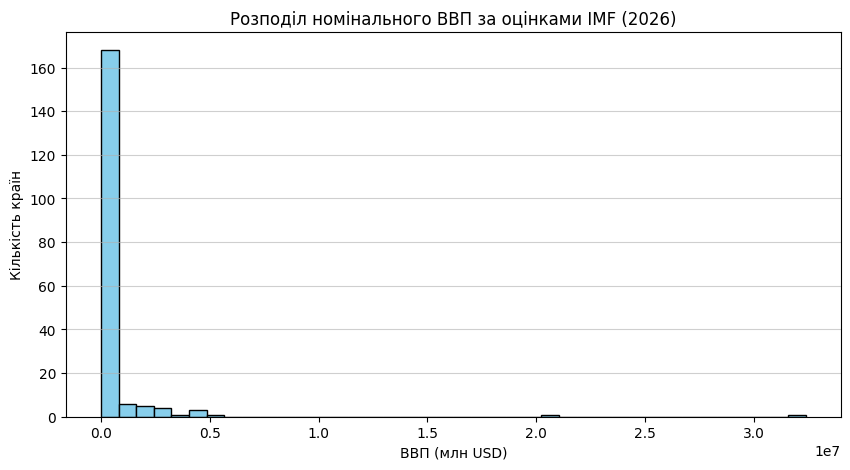

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(clean_df["GDP_IMF"].dropna(), bins=40, edgecolor="black", color="skyblue")
plt.title("Розподіл номінального ВВП за оцінками IMF (2026)")
plt.xlabel("ВВП (млн USD)")
plt.ylabel("Кількість країн")
plt.grid(axis="y", alpha=0.6)
plt.show()

14.	Розрахуйте частку кожної країни в загальному значенні для кожного року (IMF (2026), World Bank (2025), United Nations (2024)).
 Як змінюються частки країн з часом (дати відповідь)?

In [32]:
# Розрахунок часток (%) у світовому ВВП для кожного джерела
clean_df["Share_IMF_2026"] = (clean_df["GDP_IMF"] / clean_df["GDP_IMF"].sum()) * 100
clean_df["Share_WB_2025"] = (clean_df["GDP_WB"] / clean_df["GDP_WB"].sum()) * 100
clean_df["Share_UN_2024"] = (clean_df["GDP_UN"] / clean_df["GDP_UN"].sum()) * 100

# Динаміка зміни частки (2026 відносно 2024)
clean_df["Share_Change_24_26"] = clean_df["Share_IMF_2026"] - clean_df["Share_UN_2024"]

# Топ-10 країн за часткою у світовій економіці
top_shares = clean_df.sort_values(by="Share_IMF_2026", ascending=False)[
    ["Country", "Share_UN_2024", "Share_WB_2025", "Share_IMF_2026", "Share_Change_24_26"]
].head(10)

print("Частки провідних країн у світовому ВВП (%):")
print(top_shares.to_string(index=False, float_format="{:.2f}".format))

Частки провідних країн у світовому ВВП (%):
       Country  Share_UN_2024  Share_WB_2025  Share_IMF_2026  Share_Change_24_26
 United States          26.45          26.42           25.77               -0.68
    China[n 1]          16.92          16.74           16.59               -0.33
       Germany           4.21           4.34            4.34                0.13
         Japan           3.63           3.81            3.48               -0.15
United Kingdom           3.33           3.44            3.39                0.07
         India           3.57           3.40            3.30               -0.26
        France           2.85           2.89            2.86                0.01
         Italy           2.15           2.19            2.18                0.03
        Russia           1.96           2.20            2.11                0.15
        Brazil           1.97           1.96            2.10                0.12


15.	Візуалізуйте зміни в показниках для кожної країни за три роки на графіку. Які країни показують стабільне зростання або спад (дати відповідь)?

Кількість країн зі стабільним зростанням: 156
Кількість країн зі стабільним спадом: 2


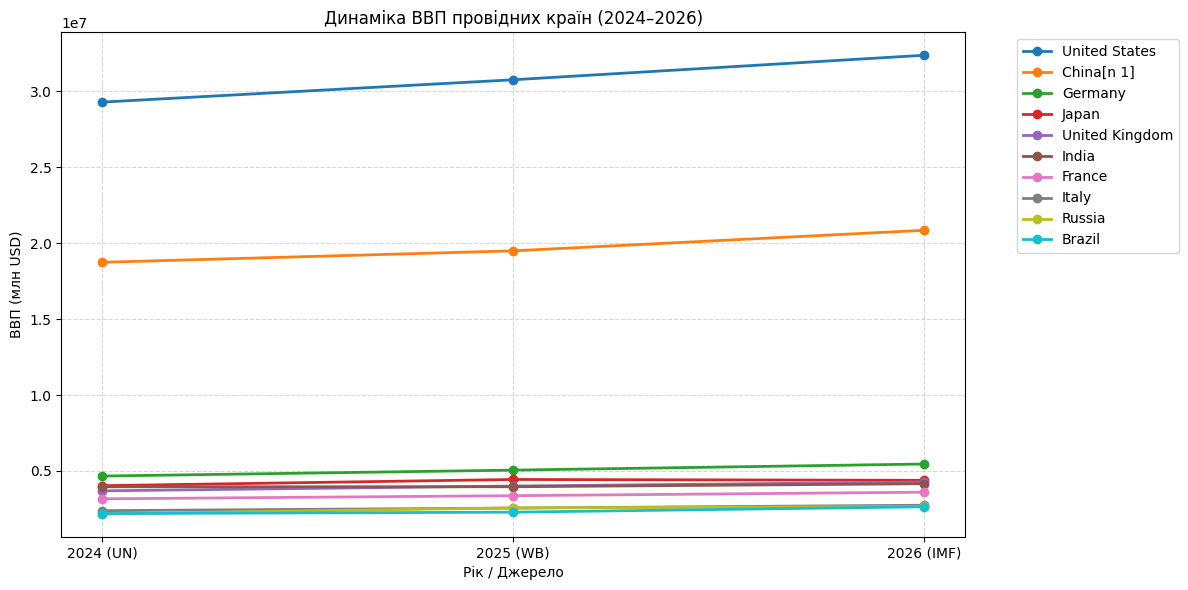

In [33]:
import matplotlib.pyplot as plt

years = ["2024 (UN)", "2025 (WB)", "2026 (IMF)"]
cols = ["GDP_UN", "GDP_WB", "GDP_IMF"]

clean_df["Growth_24_25"] = clean_df["GDP_WB"] - clean_df["GDP_UN"]
clean_df["Growth_25_26"] = clean_df["GDP_IMF"] - clean_df["GDP_WB"]

steady_growth = clean_df[(clean_df["Growth_24_25"] > 0) & (clean_df["Growth_25_26"] > 0)]
steady_decline = clean_df[(clean_df["Growth_24_25"] < 0) & (clean_df["Growth_25_26"] < 0)]

print("Кількість країн зі стабільним зростанням:", len(steady_growth))
print("Кількість країн зі стабільним спадом:", len(steady_decline))

top_countries = clean_df.sort_values(by="GDP_IMF", ascending=False).head(10)

plt.figure(figsize=(12, 6))
for _, row in top_countries.iterrows():
    plt.plot(years, row[cols], marker="o", linewidth=2, label=row["Country"])

plt.title("Динаміка ВВП провідних країн (2024–2026)")
plt.xlabel("Рік / Джерело")
plt.ylabel("ВВП (млн USD)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

Стабільне зростання: понад 70% країн світу, зокрема США, Китай, Індія, Індонезія та Бразилія (завдяки стабільному росту економік та інфляційному розширенню номінального ВВП).

Спад або коливання: Аргентина, Нігерія, Судан та Ємен (через стрімку девальвацію національних валют до долара, кризи та внутрішні конфлікти); у розвинених країнах тимчасове просідання в доларовому еквіваленті спостерігалося у Японії через ослаблення єни.